## Health Insurance Claims
Health Insurance Underwriting with Simulated Health Insurance Dataset

### 1. Setup & Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# Disable warnings in jupyter notebook
# Source - https://stackoverflow.com/a/52294671
# Posted by Ramon Crehuet
# Retrieved 2026-06-02, License - CC BY-SA 4.0

import warnings
warnings.filterwarnings('ignore')


In [3]:
my_seed = 42

### 2. Health Insurance Dataset

In [4]:
# np.random.seed(my_seed)

# # Generate 5000 datapoints
# n = 5000
# sim_df = pd.DataFrame({
#     "age": np.random.randint(18, 80, n),
#     "bmi": np.random.normal(27, 5, n).round(1),
#     "smoker": np.random.choice([0,1], n, p=[0.8, 0.2]),
#     "chronic_conditions": np.random.poisson(0.6, n),
#     "gender": np.random.choice(["M","F"], n),
#     "region": np.random.choice(["North","South","East","West"], n),
# })

# # Claims cost model (synthetic)
# sim_df["claims_cost"] = (
# sim_df["age"]*12 +
# sim_df["bmi"]*15 +
# sim_df["smoker"]*2000 +
# sim_df["chronic_conditions"]*800 +
#     np.random.normal(0, 500, n)
# ).clip(lower=0)

# sim_df.head()

In [5]:
# sim_df.shape
# (5000, 7)

In [6]:
# Medical Cost Personal Dataset on Kaggle. 
#     Age
#     BMI
#     Smoking status
#     Region
#     Number of children
#     Actual medical charges

In [7]:
df = pd.read_csv("data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.shape
# (1338, 7)

(1338, 7)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
# Convert categorical variables
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})
df["sex"] = df["sex"].map({"male": 1, "female": 0})

# Rename columns to match underwriting terminology
df = df.rename(columns={
    "charges": "claims_cost",
    "sex": "gender",
    "children": "dependents"
})

df.head()

,age,gender,bmi,dependents,smoker,region,claims_cost
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1338 non-null   int64  
 1   gender       1338 non-null   int64  
 2   bmi          1338 non-null   float64
 3   dependents   1338 non-null   int64  
 4   smoker       1338 non-null   int64  
 5   region       1338 non-null   object 
 6   claims_cost  1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


In [12]:
# Before
# dtypes: float64(2), int64(2), object(3)
# After
# dtypes: float64(2), int64(4), object(1)

In [13]:
# Count missing values in each column
missing_counts = df.isnull().sum()
print(missing_counts)

age            0
gender         0
bmi            0
dependents     0
smoker         0
region         0
claims_cost    0
dtype: int64


### Exploratory Data Analysis

In [14]:
# Set the plotting style for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

print("--- Data Snapshot ---")
print(df.head(), "\n")

--- Data Snapshot ---
   age  gender     bmi  dependents  smoker     region  claims_cost
0   19       0  27.900           0       1  southwest  16884.92400
1   18       1  33.770           1       0  southeast   1725.55230
2   28       1  33.000           3       0  southeast   4449.46200
3   33       1  22.705           0       0  northwest  21984.47061
4   32       1  28.880           0       0  northwest   3866.85520 



In [15]:
# Quick check
df.describe(include="all")

,age,gender,bmi,dependents,smoker,region,claims_cost
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338,1338.000000
unique,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,NaN,NaN,southeast,NaN
freq,NaN,NaN,NaN,NaN,NaN,364,NaN
mean,39.207025,0.505232,30.663397,1.094918,0.204783,NaN,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,NaN,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,NaN,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,NaN,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,NaN,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,NaN,16639.912515


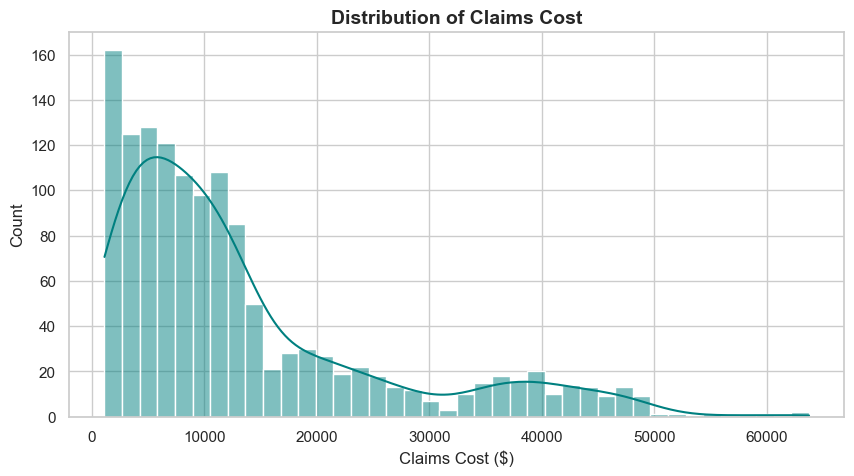

In [16]:
# Plot 1: Distribution of the Target Variable (claims_cost)
plt.figure(figsize=(10, 5))
sns.histplot(df['claims_cost'], kde=True, color='teal', bins=40)
plt.title('Distribution of Claims Cost', fontsize=14, fontweight='bold')
plt.xlabel('Claims Cost ($)')
plt.ylabel('Count')
plt.savefig("images/Distribution_of_Claims_Cost.png")  # Save Distribution of Claims Cost
plt.show()
plt.close()

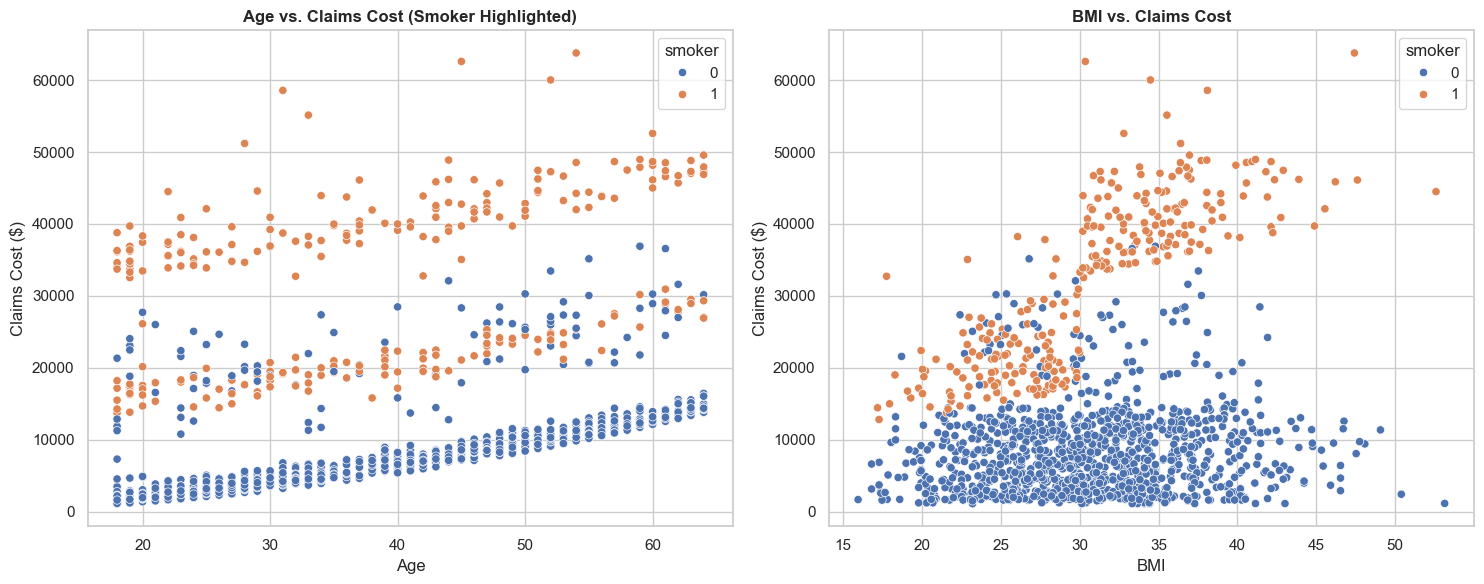

In [17]:
# Plot 2: Age & BMI vs. Claims Cost (Numerical Relationships)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# sns.scatterplot(data=df, x='age', y='claims_cost', alpha=0.4, ax=axes[0], color='blue')
sns.scatterplot(data=df, x='age', y='claims_cost', hue="smoker", ax=axes[0], color='blue')
axes[0].set_title('Age vs. Claims Cost (Smoker Highlighted)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Claims Cost ($)')

# sns.scatterplot(data=df, x='bmi', y='claims_cost', alpha=0.4, ax=axes[1], color='orange')
sns.scatterplot(data=df, x='bmi', y='claims_cost',  hue="smoker", ax=axes[1], color='orange')
axes[1].set_title('BMI vs. Claims Cost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Claims Cost ($)')

plt.tight_layout()
plt.savefig("images/Age_&_BMI_vs_Claims_Cost.png")  # Save Age & BMI vs. Claims Cost
plt.show()
plt.close()

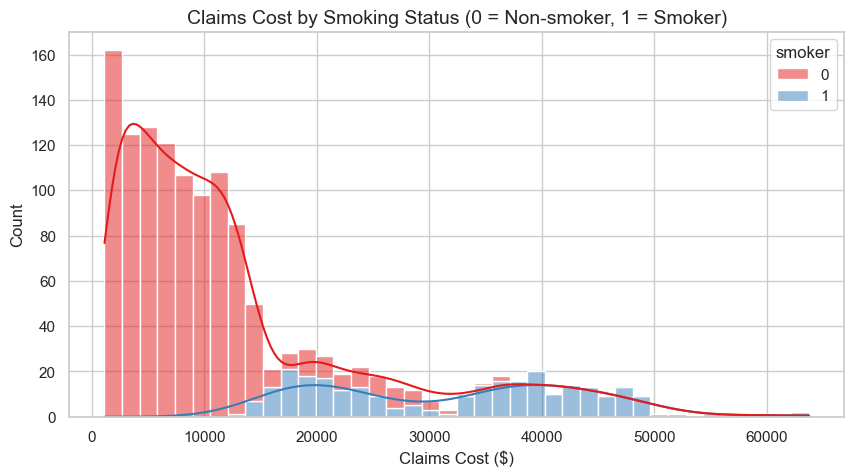

In [18]:
# Plot 3: Impact of Smoking Status (The clear bimodal split in the data)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='claims_cost', hue='smoker', kde=True, bins=40, palette='Set1', multiple='stack')
plt.title('Claims Cost by Smoking Status (0 = Non-smoker, 1 = Smoker)', fontsize=14)
# plt.title('Claims Cost by Smoking Status (0 = Non-smoker, 1 = Smoker)', fontsize=14, fontweight='bold')
plt.xlabel('Claims Cost ($)')
plt.savefig("images/Claims_Cost_Distribution_by_Smoking_Status.png")  # Save Claims Cost Distribution by Smoking Status
plt.show()
plt.close()

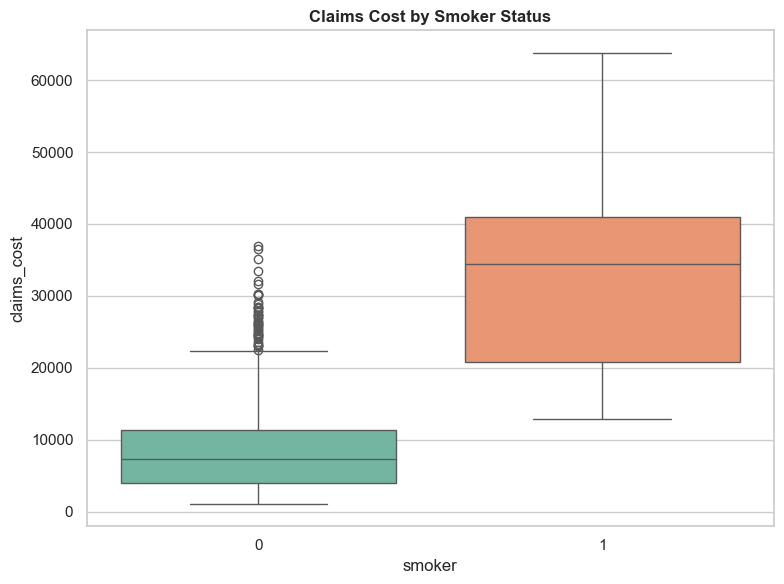

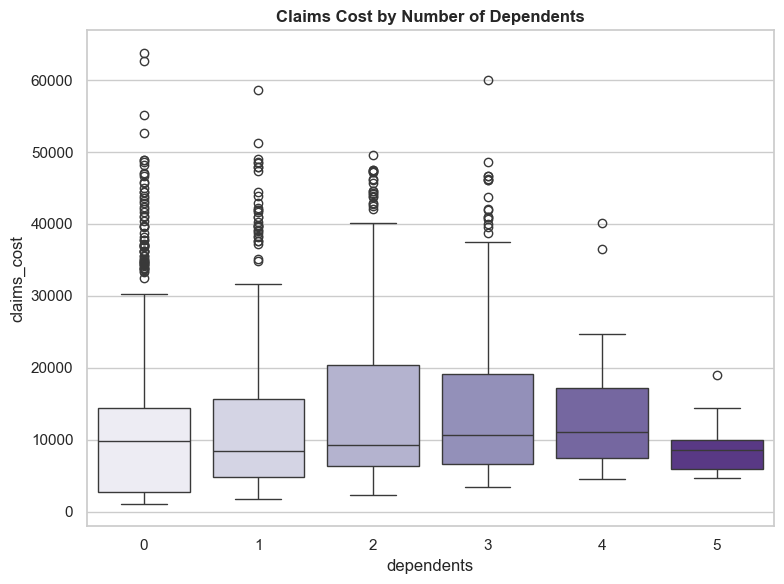

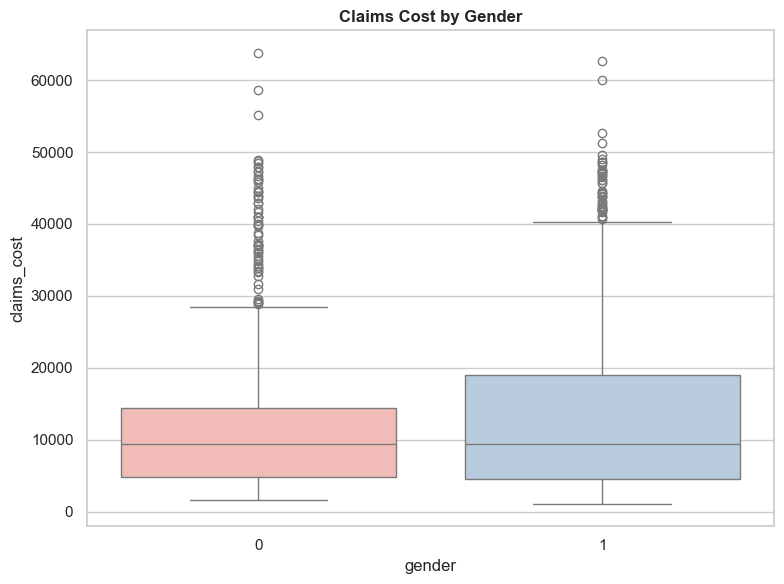

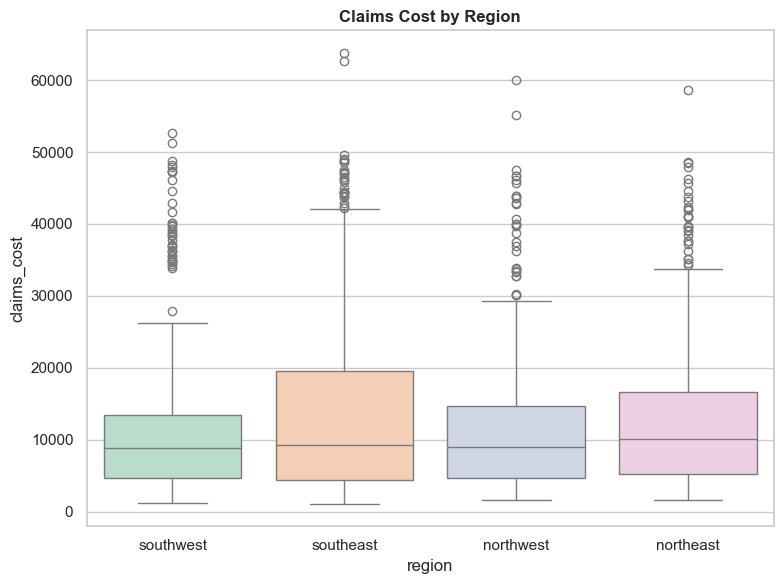

In [19]:
# Categorical Plots
# 4/6/2026 https://gemini.google.com/app
# Here is the converted code to generate, save, and display each of the four boxplots completely independently, without using subplots or loops.
# I have also added plt.close() after each plot to free up memory, which is best practice when saving multiple plots sequentially.

# 1. Smoker Status Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='smoker', y='claims_cost', palette='Set2')
plt.title('Claims Cost by Smoker Status', fontweight='bold')
plt.tight_layout()
plt.savefig("images/Claims_Cost_by_Smoker_Status.png")
plt.show()
plt.close()

# 2. Dependents Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='dependents', y='claims_cost', palette='Purples')
plt.title('Claims Cost by Number of Dependents', fontweight='bold')
plt.tight_layout()
plt.savefig("images/Claims_Cost_by_Dependents.png")
plt.show()
plt.close()

# 3. Gender Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='gender', y='claims_cost', palette='Pastel1')
plt.title('Claims Cost by Gender', fontweight='bold')
plt.tight_layout()
plt.savefig("images/Claims_Cost_by_Gender.png")
plt.show()
plt.close()

# 4. Region Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='region', y='claims_cost', palette='Pastel2')
plt.title('Claims Cost by Region', fontweight='bold')
plt.tight_layout()
plt.savefig("images/Claims_Cost_by_Region.png")
plt.show()
plt.close()

### Add plots to validate regional risks factors

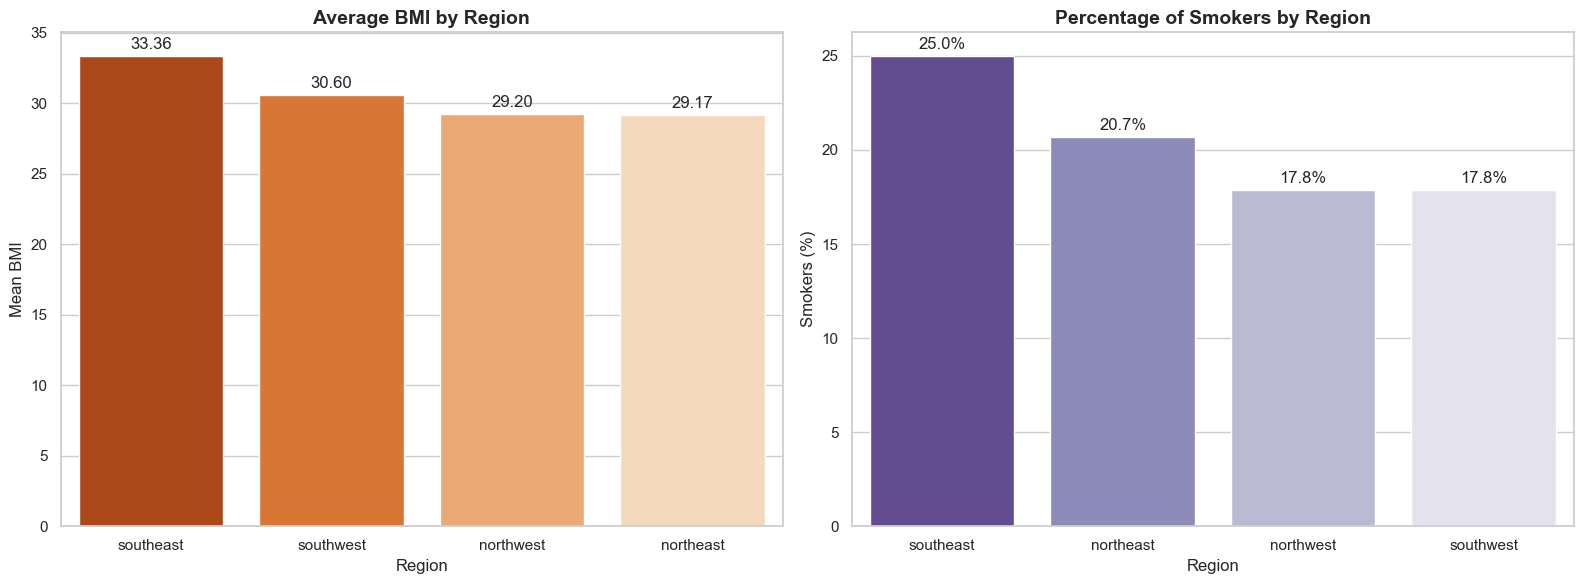

In [39]:
# Setup Plot Style 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Average BMI by Region 
# Grouping data to find the mean BMI per region
bmi_df = df.groupby('region')['bmi'].mean().reset_index().sort_values(by='bmi', ascending=False)

sns.barplot(
    data=bmi_df, 
    x='region', 
    y='bmi', 
    ax=axes[0], 
    palette="Oranges_r"
)
axes[0].set_title('Average BMI by Region', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Region', fontsize=12)
axes[0].set_ylabel('Mean BMI', fontsize=12)

# Adding data labels on top of the bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=3)

# Plot B: Smoker Proportion (%) by Region
# Calculating the percentage of smokers (assuming smoker column has 1 for smoker, 0 for non-smoker)
# If your smoker column is string ('yes'/'no'), use: df['smoker'].eq('yes').astype(int)
if df['smoker'].dtype == 'object':
    df['smoker_numeric'] = df['smoker'].apply(lambda x: 1 if str(x).lower() == 'yes' else 0)
else:
    df['smoker_numeric'] = df['smoker']

smoker_df = df.groupby('region')['smoker_numeric'].mean().reset_index().sort_values(by='smoker_numeric', ascending=False)
smoker_df['smoker_percent'] = smoker_df['smoker_numeric'] * 100

sns.barplot(
    data=smoker_df, 
    x='region', 
    y='smoker_percent', 
    ax=axes[1], 
    palette="Purples_r"
)
axes[1].set_title('Percentage of Smokers by Region', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Region', fontsize=12)
axes[1].set_ylabel('Smokers (%)', fontsize=12)

# Adding data labels on top of the bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', padding=3)

#  Display and Print Text Insights 
plt.tight_layout()
plt.show()


In [40]:
# Print Text Insights 
print("="*50)
print("STATISTICAL PROOF SUMMARY:")
print("="*50)
print(f"Highest BMI Region: {bmi_df.iloc[0]['region']} (Mean: {bmi_df.iloc[0]['bmi']:.2f})")
print(f"Highest Smoker Region: {smoker_df.iloc[0]['region']} ({smoker_df.iloc[0]['smoker_percent']:.1f}%)")
print("="*50)

STATISTICAL PROOF SUMMARY:
Highest BMI Region: southeast (Mean: 33.36)
Highest Smoker Region: southeast (25.0%)


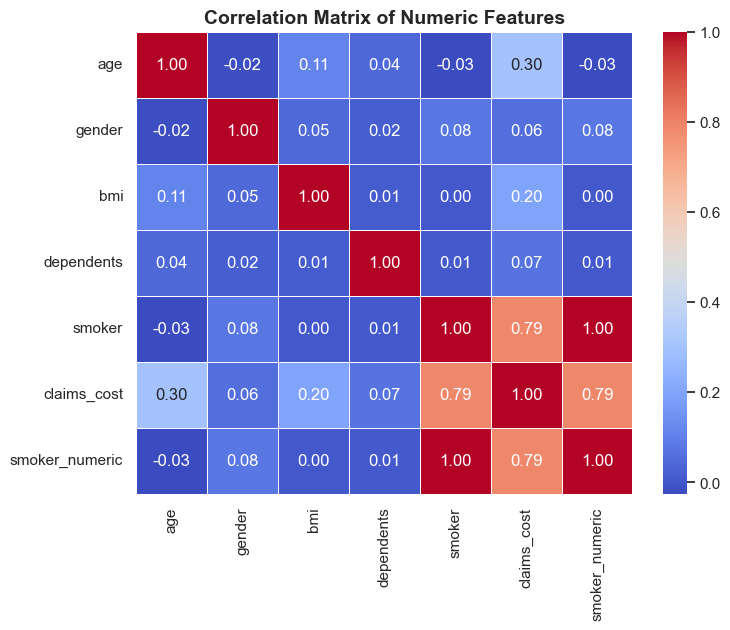

In [22]:
# Plot 5: Correlation Heatmap (To verify linear weights)
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation calculation
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.savefig("images/Correlation_Heatmap.png")  # Save Correlation Heatmap
plt.show()
plt.close()

### Risk Segmentation

In [23]:
# Update risk scoring
df["risk_score"] = (
    df["age"] * 0.02 +
    df["bmi"] * 0.03 +
    df["smoker"] * 1.5 +
    df["dependents"] * 0.2
)

df["risk_band"] = pd.qcut(df["risk_score"], q=4, labels=["Low","Medium","High","Very High"])

df["risk_band"].value_counts()

risk_band
Low          335
Very High    335
Medium       334
High         334
Name: count, dtype: int64

In [24]:
# Average claims cost by risk band
df.groupby("risk_band")["claims_cost"].mean().to_frame("avg_claims_cost")


,avg_claims_cost
risk_band,
Low,4449.170583
Medium,8998.883275
High,10921.534231
Very High,28692.338503


###  Claims Cost Prediction Model - Using Random Forest

In [25]:
features = ["age", "bmi", "smoker", "dependents", "gender"]
X = df[features]
y = df["claims_cost"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=my_seed)

model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R²:", r2_score(y_test, preds))

MAE: 2519.5997338749326
R²: 0.8590419003231705


In [26]:
# MAE: 2301.2857077285516
# R²: 0.8898903052751136

In [27]:
# Feature importance for underwriting transparency
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
fi


smoker        0.608966
bmi           0.228306
age           0.135629
dependents    0.020523
gender        0.006576
dtype: float64

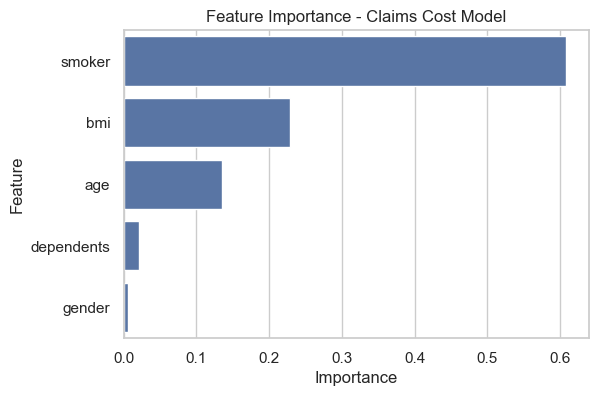

In [28]:
plt.figure(figsize=(6,4))
sns.barplot(x=fi.values, y=fi.index)
plt.title("Feature Importance - Claims Cost Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("images/Feature_Importance.png")  # Save Feature Importance
plt.show()

### Pricing Adequacy Check

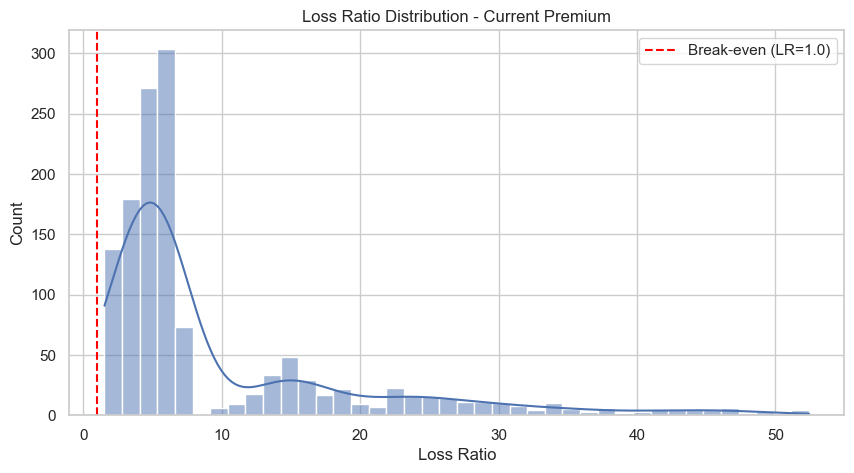

In [29]:
# Legacy-style age-based premium
df["current_premium"] = df["age"] * 30 + 200

# Assume current premium is based on simple age-based pricing
# df["current_premium"] = df["age"] * 20 + 300

df["loss_ratio"] = df["claims_cost"] / df["current_premium"]

plt.figure(figsize=(10,5))
sns.histplot(df["loss_ratio"], bins=40, kde=True)
plt.axvline(1.0, color="red", linestyle="--", label="Break-even (LR=1.0)")
plt.title("Loss Ratio Distribution - Current Premium")
plt.xlabel("Loss Ratio")
plt.legend()
plt.savefig("images/Loss_Ratio_Distribution.png")  # Save Loss Ratio Distribution
plt.show()

In [30]:
# df.groupby("risk_band")["loss_ratio"].mean()
df.groupby("risk_band")["loss_ratio"].mean().to_frame("avg_loss_ratio")

,avg_loss_ratio
risk_band,
Low,4.575217
Medium,6.020588
High,6.748439
Very High,21.772352


### Scenario Testing: New Pricing Strategy

In [31]:
# Alternate pricing
# df["proposed_premium"] = (
#     250 +
#     df["risk_score"] * 220
# )

In [32]:
df["proposed_premium"] = (
    300 +
    df["risk_score"]*150 +
    df["dependents"]*50
)

In [33]:
df["new_loss_ratio"] = df["claims_cost"] / df["proposed_premium"]

df[["loss_ratio","new_loss_ratio"]].describe()

,loss_ratio,new_loss_ratio
count,1338.000000,1338.000000
mean,9.784223,17.754208
std,9.834944,13.750453
min,1.516046,1.961713
25%,4.116437,7.340466
50%,5.658339,13.496467
75%,13.242282,22.331565
max,52.422548,78.573063


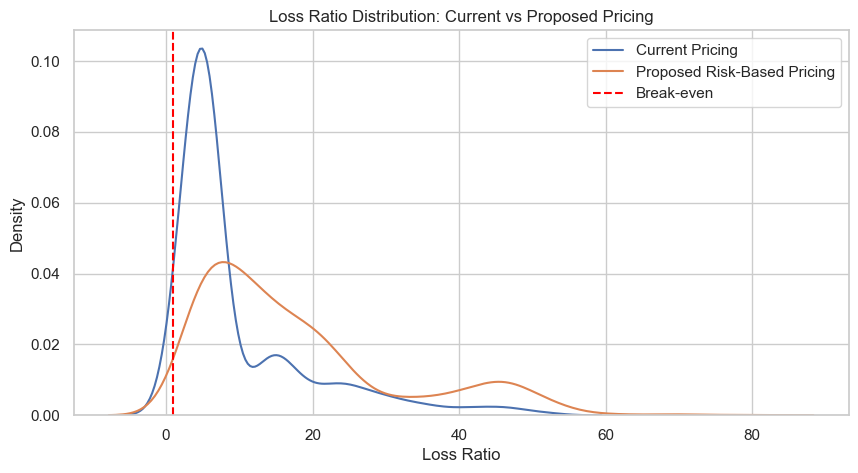

In [34]:
# Loss Ratio Distribution: Current vs Proposed Pricing

plt.figure(figsize=(10,5))
sns.kdeplot(df["loss_ratio"], label="Current Pricing")
sns.kdeplot(df["new_loss_ratio"], label="Proposed Risk-Based Pricing")
plt.axvline(1.0, color="red", linestyle="--", label="Break-even")
plt.title("Loss Ratio Distribution: Current vs Proposed Pricing")
plt.xlabel("Loss Ratio")
plt.legend()
plt.show()


### Impact Summary

In [35]:
summary = df.groupby("risk_band")[[
    "claims_cost",
    "current_premium",
    "proposed_premium",
    "loss_ratio",
    "new_loss_ratio"
]].mean().round(2)

summary

,claims_cost,current_premium,proposed_premium,loss_ratio,new_loss_ratio
risk_band,,,,,
Low,4449.17,960.93,529.86,4.58,8.23
Medium,8998.88,1472.66,631.30,6.02,14.49
High,10921.53,1622.22,724.91,6.75,15.35
Very High,28692.34,1450.06,870.98,21.77,32.93


In [36]:
# # Save generated dataset
# df.to_csv("health-insurance-output.csv", index=False)